In [1]:
"""Quick notebook showing the difference between RUL in cycles vs. Ah."""

'Quick notebook showing the difference between RUL in cycles vs. Ah.'

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [3]:
repo_root = Path().absolute().parent.parent

features_path = repo_root / "data" / "interim" / "features.parquet"
print(f"Loading features from: {features_path}")

if not features_path.exists():
    raise FileNotFoundError(
        f"Features file not found at {features_path}. "
        "Run feature extraction first (src/data/make_features.py)."
    )

features_df = pd.read_parquet(features_path)
features_df.head()

Loading features from: /Users/clarafarias/code/severson_features_soh_rul/data/interim/features.parquet


,cell,cycle,SOH,charge_policy,throughput_ah_cycle,V_mean,V_median,V_std,V_iqr,V_kurtosis,...,charge_I_iqr,charge_I_kurtosis,charge_T_mean,charge_T_median,charge_T_std,charge_T_iqr,charge_T_kurtosis,RUL,throughput_ah_cumulative,RUL_THROUGHPUT
0,b1c16,1,98.287855,5.4C(60%)-3.6C,1.962667,3.113074,3.364936,0.525309,0.591460,-0.184578,...,5.119626,-1.594107,31.921679,31.924490,1.525122,2.170259,-0.781212,859,1.962667,1637.357551
1,b1c16,2,98.398618,5.4C(60%)-3.6C,1.964915,3.114386,3.364437,0.523411,0.591736,-0.176401,...,5.096980,-1.570353,31.944442,31.971531,1.503099,2.229275,-0.820880,858,3.927582,1635.392637
2,b1c16,3,98.487136,5.4C(60%)-3.6C,1.966634,3.112558,3.332523,0.518185,0.603142,-0.171407,...,5.145446,-1.527270,31.936617,31.965219,1.510386,2.145249,-0.831725,857,5.894215,1633.426003
3,b1c16,4,98.553618,5.4C(60%)-3.6C,1.967932,3.113084,3.336795,0.516932,0.604378,-0.166349,...,5.071867,-1.580688,31.965595,31.931253,1.527041,2.281160,-0.847546,856,7.862147,1631.458072
4,b1c16,5,98.604936,5.4C(60%)-3.6C,1.968876,3.116186,3.357531,0.517422,0.578248,-0.137306,...,5.118568,-1.536637,31.904419,31.945330,1.505957,2.189388,-0.772270,855,9.831023,1629.489195


In [4]:
required_cols = {"cell", "cycle", "RUL", "RUL_THROUGHPUT"}
missing_cols = required_cols - set(features_df.columns)
if missing_cols:
    raise ValueError(
        f"Missing required columns for comparison plot: {sorted(missing_cols)}"
    )

# Set to a specific cell id if desired, e.g. "b2c32".
example_cell = "b1c23"

available_cells = sorted(features_df["cell"].astype(str).unique().tolist())
if not available_cells:
    raise ValueError("No cells found in features dataset.")

if example_cell is None:
    example_cell = available_cells[0]

cell_df = (
    features_df[features_df["cell"].astype(str) == str(example_cell)]
    .sort_values("cycle")
    .copy()
)

if cell_df.empty:
    raise ValueError(f"Cell {example_cell} not found in features dataset.")

print(f"Example cell: {example_cell}")
print(f"Number of cycles: {cell_df.shape[0]}")
cell_df[["cell", "cycle", "RUL", "RUL_THROUGHPUT"]].head()

Example cell: b1c23
Number of cycles: 1012


,cell,cycle,RUL,RUL_THROUGHPUT
30108,b1c23,1,1011,1914.230286
30109,b1c23,2,1010,1912.267930
30110,b1c23,3,1009,1910.304368
30111,b1c23,4,1008,1908.339944
30112,b1c23,5,1007,1906.375252


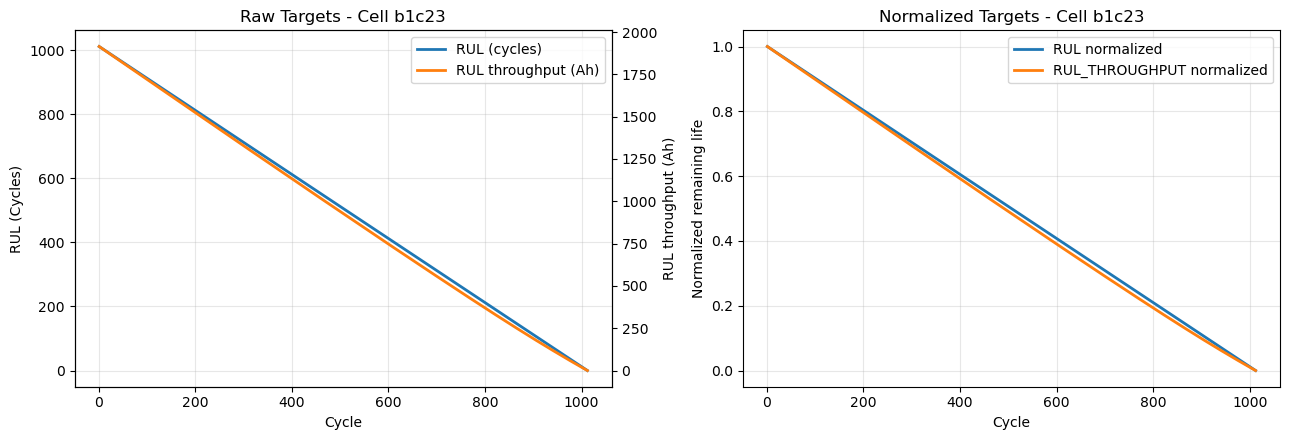

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax1 = axes[0]
ax2 = ax1.twinx()

# Raw targets (different units).
(l1,) = ax1.plot(
    cell_df["cycle"],
    cell_df["RUL"],
    label="RUL (cycles)",
    linewidth=2,
    c="C0",
)
(l2,) = ax2.plot(
    cell_df["cycle"],
    cell_df["RUL_THROUGHPUT"],
    label="RUL throughput (Ah)",
    linewidth=2,
    c="C1",
)
ax1.set_title(f"Raw Targets - Cell {example_cell}")
ax1.set_xlabel("Cycle")
ax1.set_ylabel("RUL (Cycles)")
ax2.set_ylabel("RUL throughput (Ah)")
ax1.grid(alpha=0.3)
ax1.legend(handles=[l1, l2])

# Normalized comparison (shape only).
rul_norm = cell_df["RUL"] / cell_df["RUL"].max()
rul_through_norm = cell_df["RUL_THROUGHPUT"] / cell_df["RUL_THROUGHPUT"].max()

axes[1].plot(
    cell_df["cycle"],
    rul_norm,
    label="RUL normalized",
    linewidth=2,
    c="C0",
)
axes[1].plot(
    cell_df["cycle"],
    rul_through_norm,
    label="RUL_THROUGHPUT normalized",
    linewidth=2,
    c="C1",
)
axes[1].set_title(f"Normalized Targets - Cell {example_cell}")
axes[1].set_xlabel("Cycle")
axes[1].set_ylabel("Normalized remaining life")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()